<a href="https://colab.research.google.com/github/YoungJang-KR/semiconductor-fault-detection/blob/main/01_practice02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 코랩-드라이브 연동
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# pandas 라이브러리
import pandas as pd

# train 폴더의 01_M01_DC_train.csv 파일 살펴보기
path_train = '/content/drive/MyDrive/phm18/train/01_M01_DC_train.csv'

df_train = pd.read_csv(path_train)
print("행, 렬:", df_train.shape)
print("열 항목:", df_train.columns.tolist())

행, 렬: (3124704, 24)
열 항목: ['time', 'Tool', 'stage', 'Lot', 'runnum', 'recipe', 'recipe_step', 'IONGAUGEPRESSURE', 'ETCHBEAMVOLTAGE', 'ETCHBEAMCURRENT', 'ETCHSUPPRESSORVOLTAGE', 'ETCHSUPPRESSORCURRENT', 'FLOWCOOLFLOWRATE', 'FLOWCOOLPRESSURE', 'ETCHGASCHANNEL1READBACK', 'ETCHPBNGASREADBACK', 'FIXTURETILTANGLE', 'ROTATIONSPEED', 'ACTUALROTATIONANGLE', 'FIXTURESHUTTERPOSITION', 'ETCHSOURCEUSAGE', 'ETCHAUXSOURCETIMER', 'ETCHAUX2SOURCETIMER', 'ACTUALSTEPDURATION']


In [3]:
path_ttf = '/content/drive/MyDrive/phm18/train_ttf/01_M01_DC_train.csv'

df_ttf = pd.read_csv(path_ttf)
print("행, 렬:", df_ttf.shape)
print("열 항목:", df_ttf.columns.tolist())

행, 렬: (3124704, 4)
열 항목: ['time', 'TTF_FlowCool Pressure Dropped Below Limit', 'TTF_Flowcool Pressure Too High Check Flowcool Pump', 'TTF_Flowcool leak']


In [4]:
# column index 이름 변경
df_ttf = df_ttf.rename( columns={
    'TTF_FlowCool Pressure Dropped Below Limit': 'TTF_pressure_drop',
    'TTF_Flowcool Pressure Too High Check Flowcool Pump': 'TTF_pressure_high',
    'TTF_Flowcool leak': 'TTF_leak'})

# 이름 변경이 잘 되었는지 확인
print("열 항목:", df_ttf.columns.tolist())

열 항목: ['time', 'TTF_pressure_drop', 'TTF_pressure_high', 'TTF_leak']


In [5]:
# 시간 기준으로 merge
df = df_train.merge(df_ttf, on='time')

# merge가 잘 되었나 확인
print("행, 렬:", df.shape)
print("열 항목:", df.columns.tolist())

행, 렬: (3135742, 27)
열 항목: ['time', 'Tool', 'stage', 'Lot', 'runnum', 'recipe', 'recipe_step', 'IONGAUGEPRESSURE', 'ETCHBEAMVOLTAGE', 'ETCHBEAMCURRENT', 'ETCHSUPPRESSORVOLTAGE', 'ETCHSUPPRESSORCURRENT', 'FLOWCOOLFLOWRATE', 'FLOWCOOLPRESSURE', 'ETCHGASCHANNEL1READBACK', 'ETCHPBNGASREADBACK', 'FIXTURETILTANGLE', 'ROTATIONSPEED', 'ACTUALROTATIONANGLE', 'FIXTURESHUTTERPOSITION', 'ETCHSOURCEUSAGE', 'ETCHAUXSOURCETIMER', 'ETCHAUX2SOURCETIMER', 'ACTUALSTEPDURATION', 'TTF_pressure_drop', 'TTF_pressure_high', 'TTF_leak']


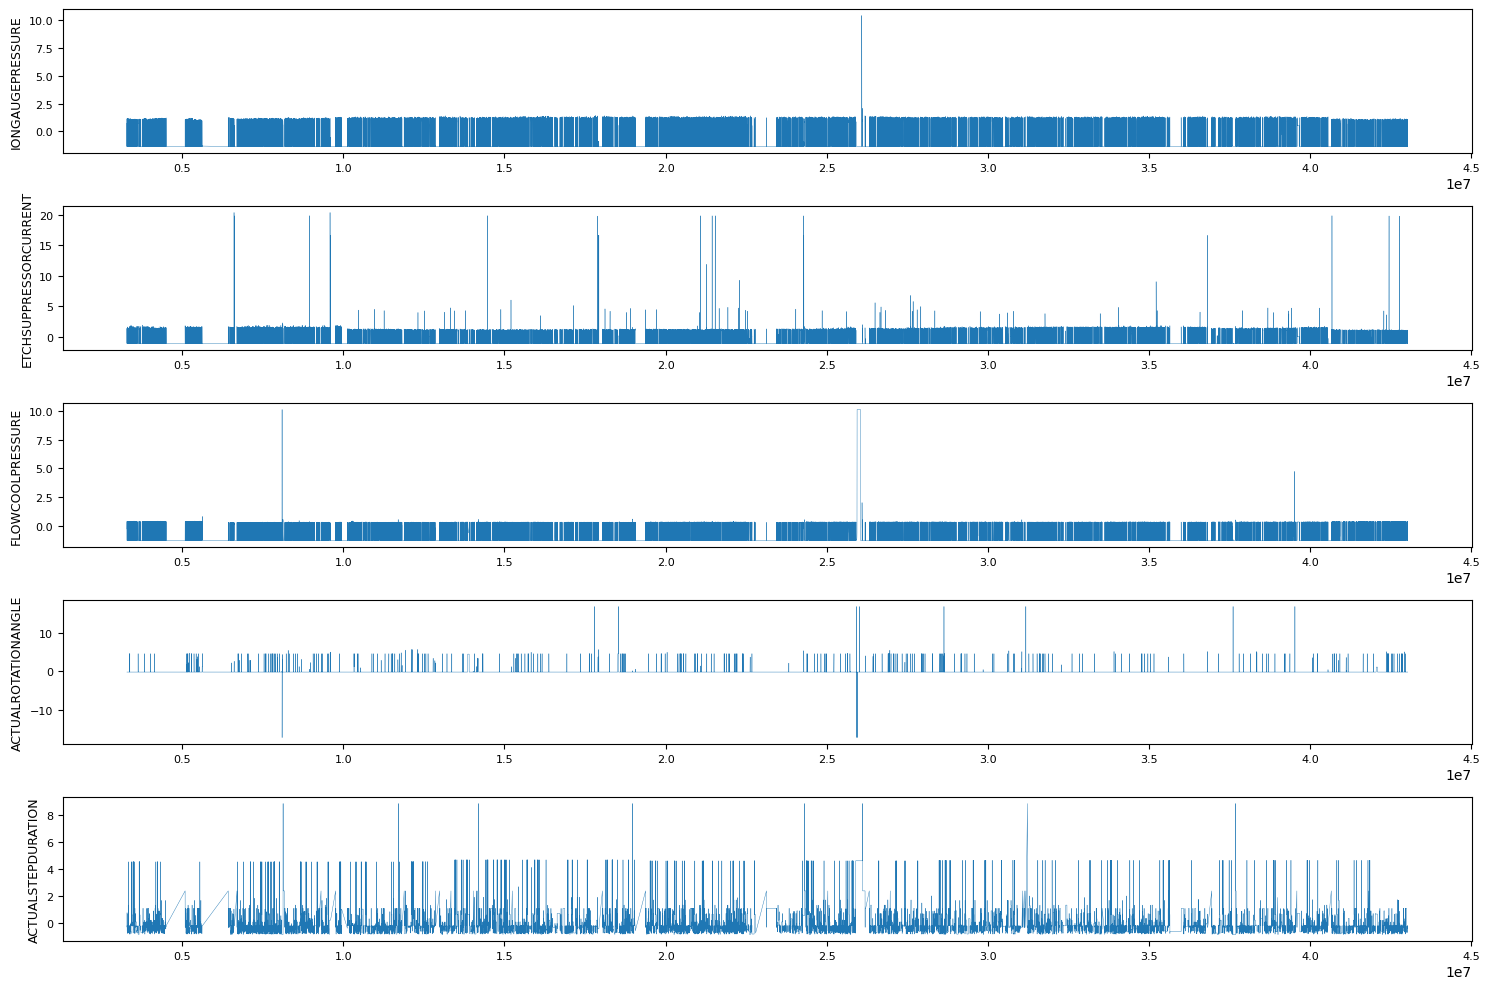

In [8]:
# 시간 기준 시각화
import matplotlib.pyplot as plt

sensor_cols = ['IONGAUGEPRESSURE', 'ETCHSUPPRESSORCURRENT',
              'FLOWCOOLPRESSURE', 'ACTUALROTATIONANGLE', 'ACTUALSTEPDURATION']

# 복습
fig, axes = plt.subplots( len(sensor_cols), 1, figsize=(15, len(sensor_cols)*2) )

for i, col in enumerate(sensor_cols):
  axes[i].plot( df['time'], df[col], linewidth=0.3 )
  axes[i].set_ylabel(col, fontsize=9)
  axes[i].tick_params(labelsize=8)

plt.tight_layout()
plt.show()

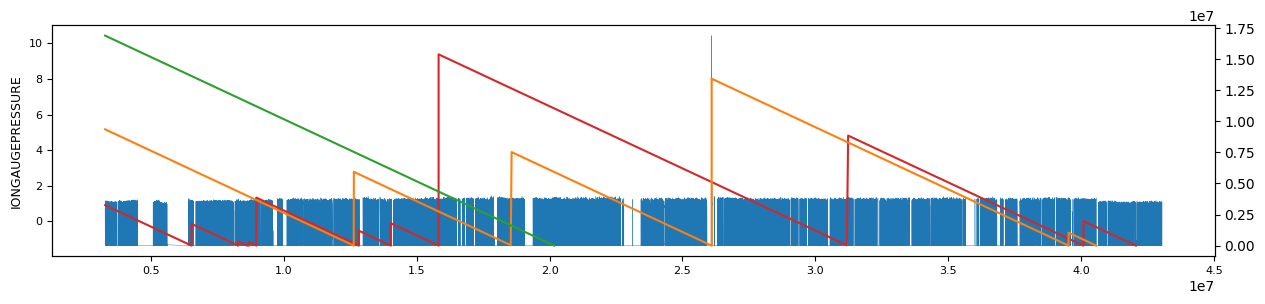

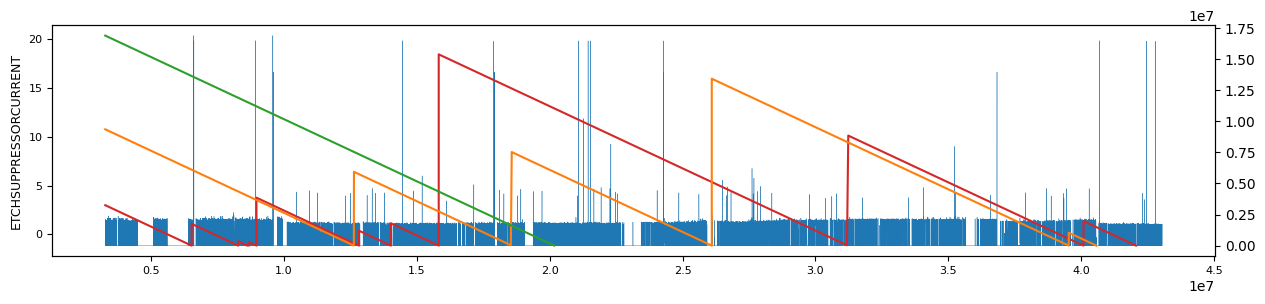

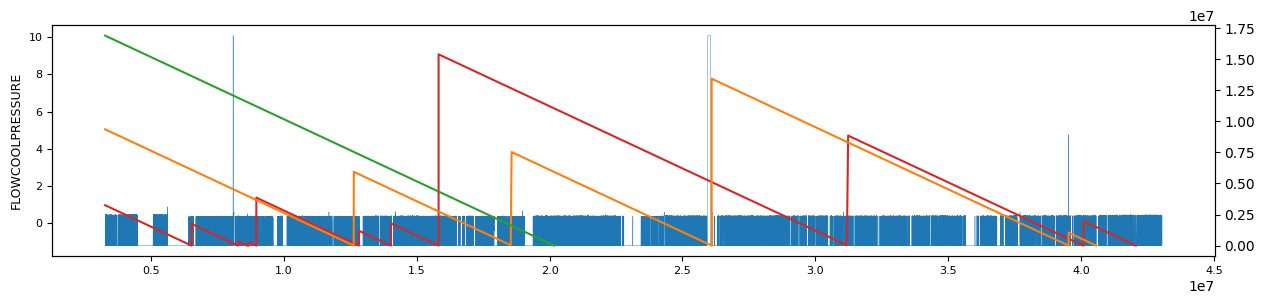

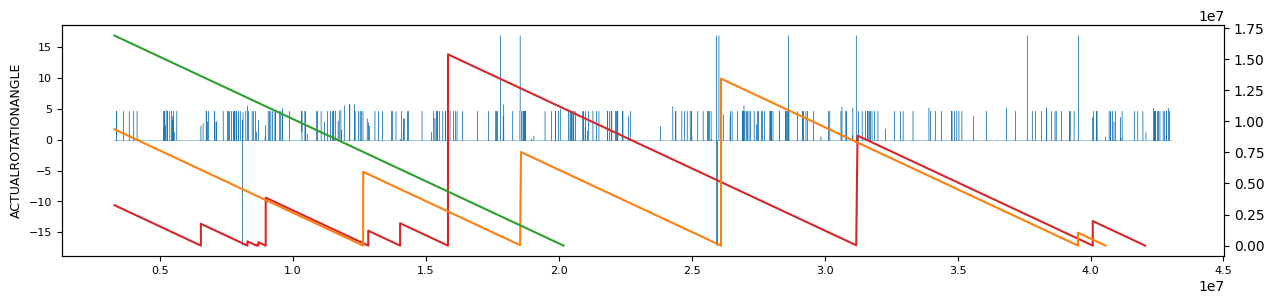

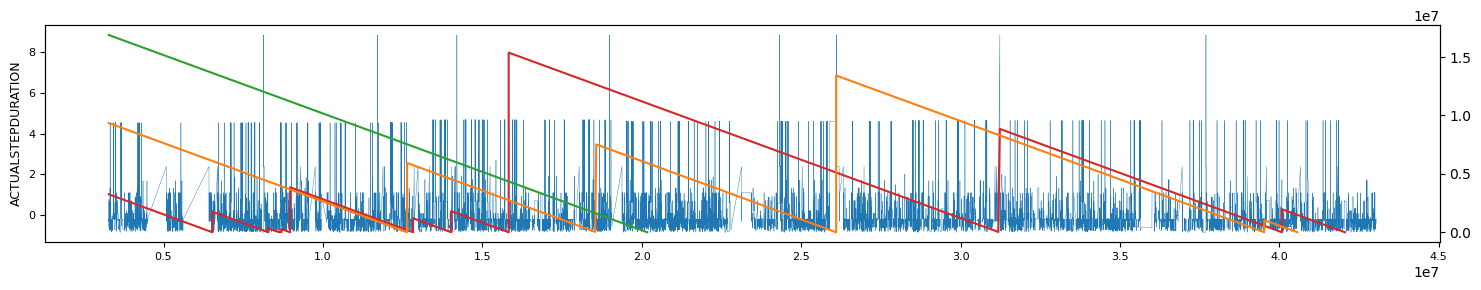

In [17]:
for sensor in sensor_cols:
  fig, ax1 = plt.subplots(figsize=(15, 3))
  ax1.plot( df['time'], df[sensor], linewidth=0.3 )
  ax1.set_ylabel(sensor, fontsize=9)
  ax1.tick_params(labelsize=8)

  ax2 = ax1.twinx()
  ax2.plot( df['time'], df['TTF_pressure_drop'], color='tab:red')
  ax2.plot( df['time'], df['TTF_pressure_high'], color='tab:orange')
  ax2.plot( df['time'], df['TTF_leak'], color='tab:green')

plt.tight_layout()
plt.show()

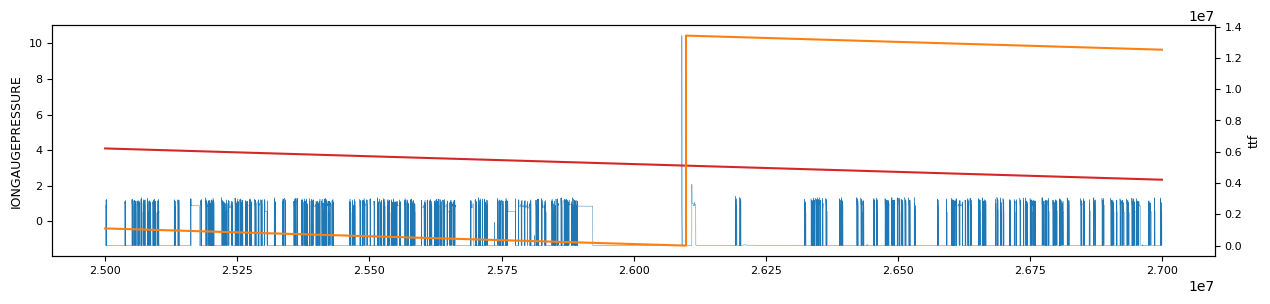

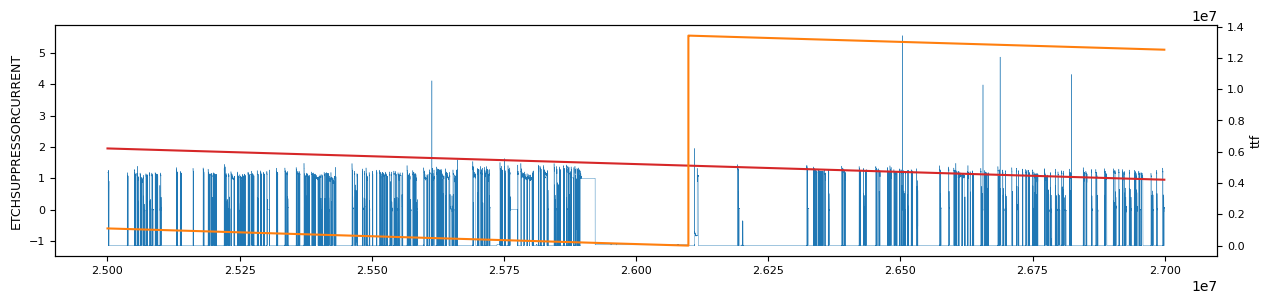

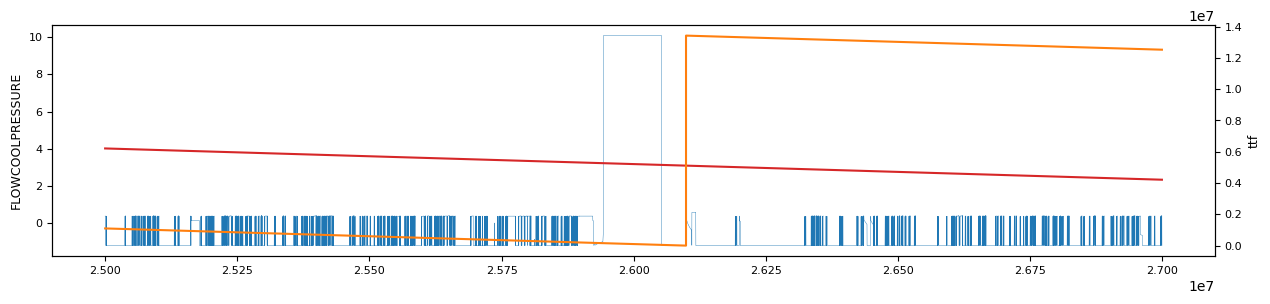

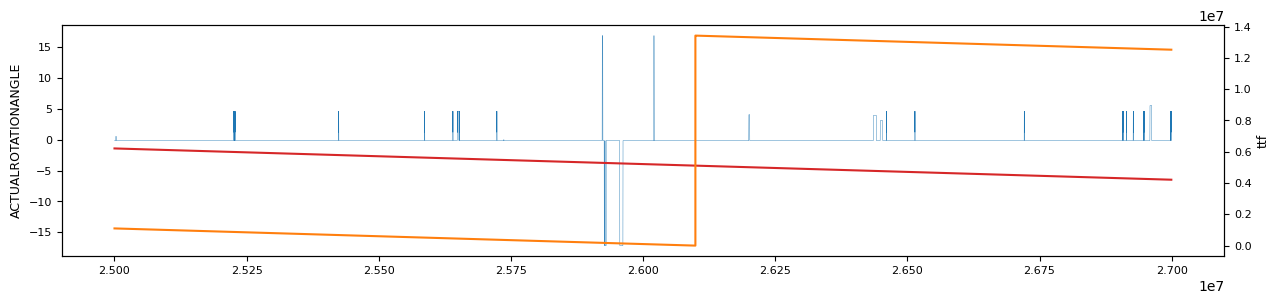

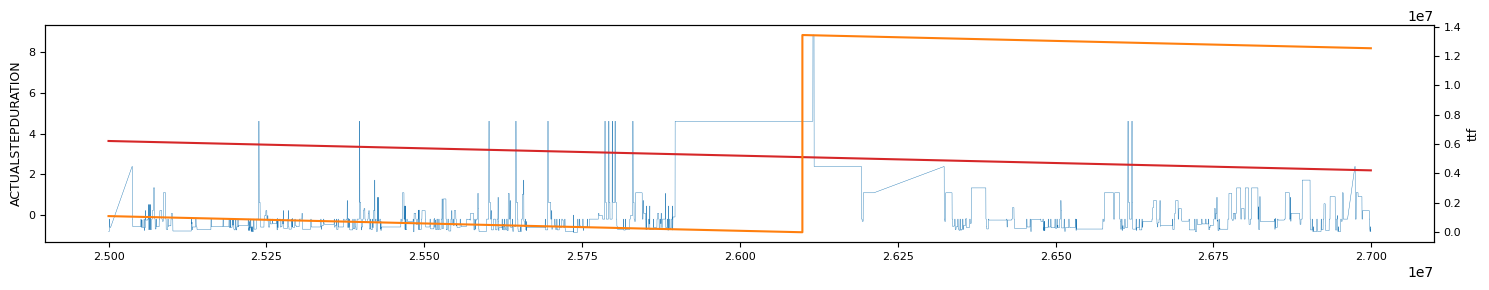

In [24]:
window = df[ (df['time'] > 2.5e7) & (df['time'] < 2.7e7) ]

ttf_cols = [ 'TTF_pressure_drop', 'TTF_pressure_high'] # TTF_leak 제외

for sensor in sensor_cols:
  fig, ax1 = plt.subplots(figsize=(15, 3))
  ax1.plot( window['time'], window[sensor], linewidth=0.3 )
  ax1.set_ylabel(sensor, fontsize=9)
  ax1.tick_params(labelsize=8)

  ax2 = ax1.twinx()
  ax2.plot( window['time'], window['TTF_pressure_drop'], color='tab:red' )
  ax2.plot( window['time'], window['TTF_pressure_high'], color='tab:orange')
  ax2.plot( window['time'], window['TTF_leak'], color='tab:green')
  ax2.set_ylabel('ttf', fontsize=9)
  ax2.tick_params(labelsize=8)

plt.tight_layout()
plt.show()

In [25]:
# 상관관계 파악

train_cols = [ 'IONGAUGEPRESSURE', 'ETCHBEAMVOLTAGE', 'ETCHBEAMCURRENT',
              'ETCHSUPPRESSORVOLTAGE', 'ETCHSUPPRESSORCURRENT', 'FLOWCOOLFLOWRATE',
               'FLOWCOOLPRESSURE', 'ETCHGASCHANNEL1READBACK', 'ETCHPBNGASREADBACK',
               'FIXTURETILTANGLE', 'ROTATIONSPEED', 'ACTUALROTATIONANGLE',
               'FIXTURESHUTTERPOSITION', 'ETCHSOURCEUSAGE', 'ETCHAUXSOURCETIMER',
               'ETCHAUX2SOURCETIMER', 'ACTUALSTEPDURATION' ]

corr = df[ train_cols + ttf_cols ].corr()
corr_ttf = corr.loc[train_cols, ttf_cols]
print(corr_ttf)

                         TTF_pressure_drop  TTF_pressure_high
IONGAUGEPRESSURE                  0.010567           0.008017
ETCHBEAMVOLTAGE                   0.013649           0.011060
ETCHBEAMCURRENT                   0.006055           0.007851
ETCHSUPPRESSORVOLTAGE            -0.003918           0.013824
ETCHSUPPRESSORCURRENT            -0.015696           0.026035
FLOWCOOLFLOWRATE                  0.008946           0.022253
FLOWCOOLPRESSURE                  0.000423          -0.103868
ETCHGASCHANNEL1READBACK           0.003286           0.016508
ETCHPBNGASREADBACK                0.007073           0.028553
FIXTURETILTANGLE                  0.006168          -0.026848
ROTATIONSPEED                     0.086915          -0.014173
ACTUALROTATIONANGLE              -0.037254           0.001671
FIXTURESHUTTERPOSITION            0.007495          -0.092108
ETCHSOURCEUSAGE                  -0.159575           0.047198
ETCHAUXSOURCETIMER                0.313597          -0.439621
ETCHAUX2

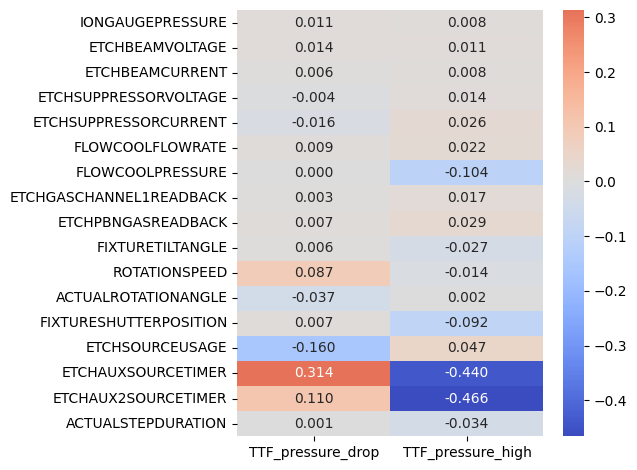

In [26]:
import seaborn as sns

sns.heatmap(corr_ttf,
            annot=True,
            fmt = '.3f',
            cmap = 'coolwarm',
            center = 0)

plt.tight_layout()
plt.show()

In [28]:
# describe로 정보 파악하기
print(df[ ['TTF_pressure_drop', 'TTF_pressure_high', 'TTF_leak'] ].describe())

       TTF_pressure_drop  TTF_pressure_high      TTF_leak
count       3.063960e+06       2.977064e+06  1.375078e+06
mean        4.703427e+06       4.689157e+06  8.145258e+06
std         4.215546e+06       3.367224e+06  4.681798e+06
min         0.000000e+00       0.000000e+00  0.000000e+00
25%         1.174378e+06       1.839644e+06  4.257481e+06
50%         3.235546e+06       4.396413e+06  8.189178e+06
75%         7.401371e+06       6.612137e+06  1.200806e+07
max         1.538524e+07       1.342678e+07  1.689183e+07


In [29]:
# TTF_pressure_high 고장 예측을 위한 threshold 설정
threshold = 1839644

df['label_pressure_high'] = (df['TTF_pressure_high'] <= threshold).astype(int)

print(df['label_pressure_high'].value_counts())

label_pressure_high
0    2391475
1     744267
Name: count, dtype: int64


In [33]:
# 복습
df_normal = df[ df['label_pressure_high'] == 0 ]
df_prefault = df[ df['label_pressure_high'] == 1 ]

print(f"정상구간: {len(df_normal):,}행")
print(f"고장 직전: {len(df_prefault):,}행")

정상구간: 2,391,475행
고장 직전: 744,267행


In [36]:
print("=== 정상 구간에서 센서값 평균 ===")
print( df_normal[train_cols].mean() )
print("=== 고장 직전에서 센서값 평균 ===")
print( df_prefault[train_cols].mean() )

=== 정상 구간에서 센서값 평균 ===
IONGAUGEPRESSURE          -0.015832
ETCHBEAMVOLTAGE           -0.016416
ETCHBEAMCURRENT           -0.023020
ETCHSUPPRESSORVOLTAGE     -0.026977
ETCHSUPPRESSORCURRENT      0.027016
FLOWCOOLFLOWRATE          -0.032473
FLOWCOOLPRESSURE          -0.083832
ETCHGASCHANNEL1READBACK   -0.025994
ETCHPBNGASREADBACK        -0.022729
FIXTURETILTANGLE           0.013098
ROTATIONSPEED              0.044963
ACTUALROTATIONANGLE        0.015539
FIXTURESHUTTERPOSITION     0.622081
ETCHSOURCEUSAGE           -0.181594
ETCHAUXSOURCETIMER        -0.021931
ETCHAUX2SOURCETIMER       -0.264439
ACTUALSTEPDURATION        -0.048810
dtype: float64
=== 고장 직전에서 센서값 평균 ===
IONGAUGEPRESSURE           0.006362
ETCHBEAMVOLTAGE           -0.055311
ETCHBEAMCURRENT           -0.050934
ETCHSUPPRESSORVOLTAGE     -0.004060
ETCHSUPPRESSORCURRENT     -0.049252
FLOWCOOLFLOWRATE          -0.029731
FLOWCOOLPRESSURE           0.337795
ETCHGASCHANNEL1READBACK   -0.029843
ETCHPBNGASREADBACK        -0.033979
FIX

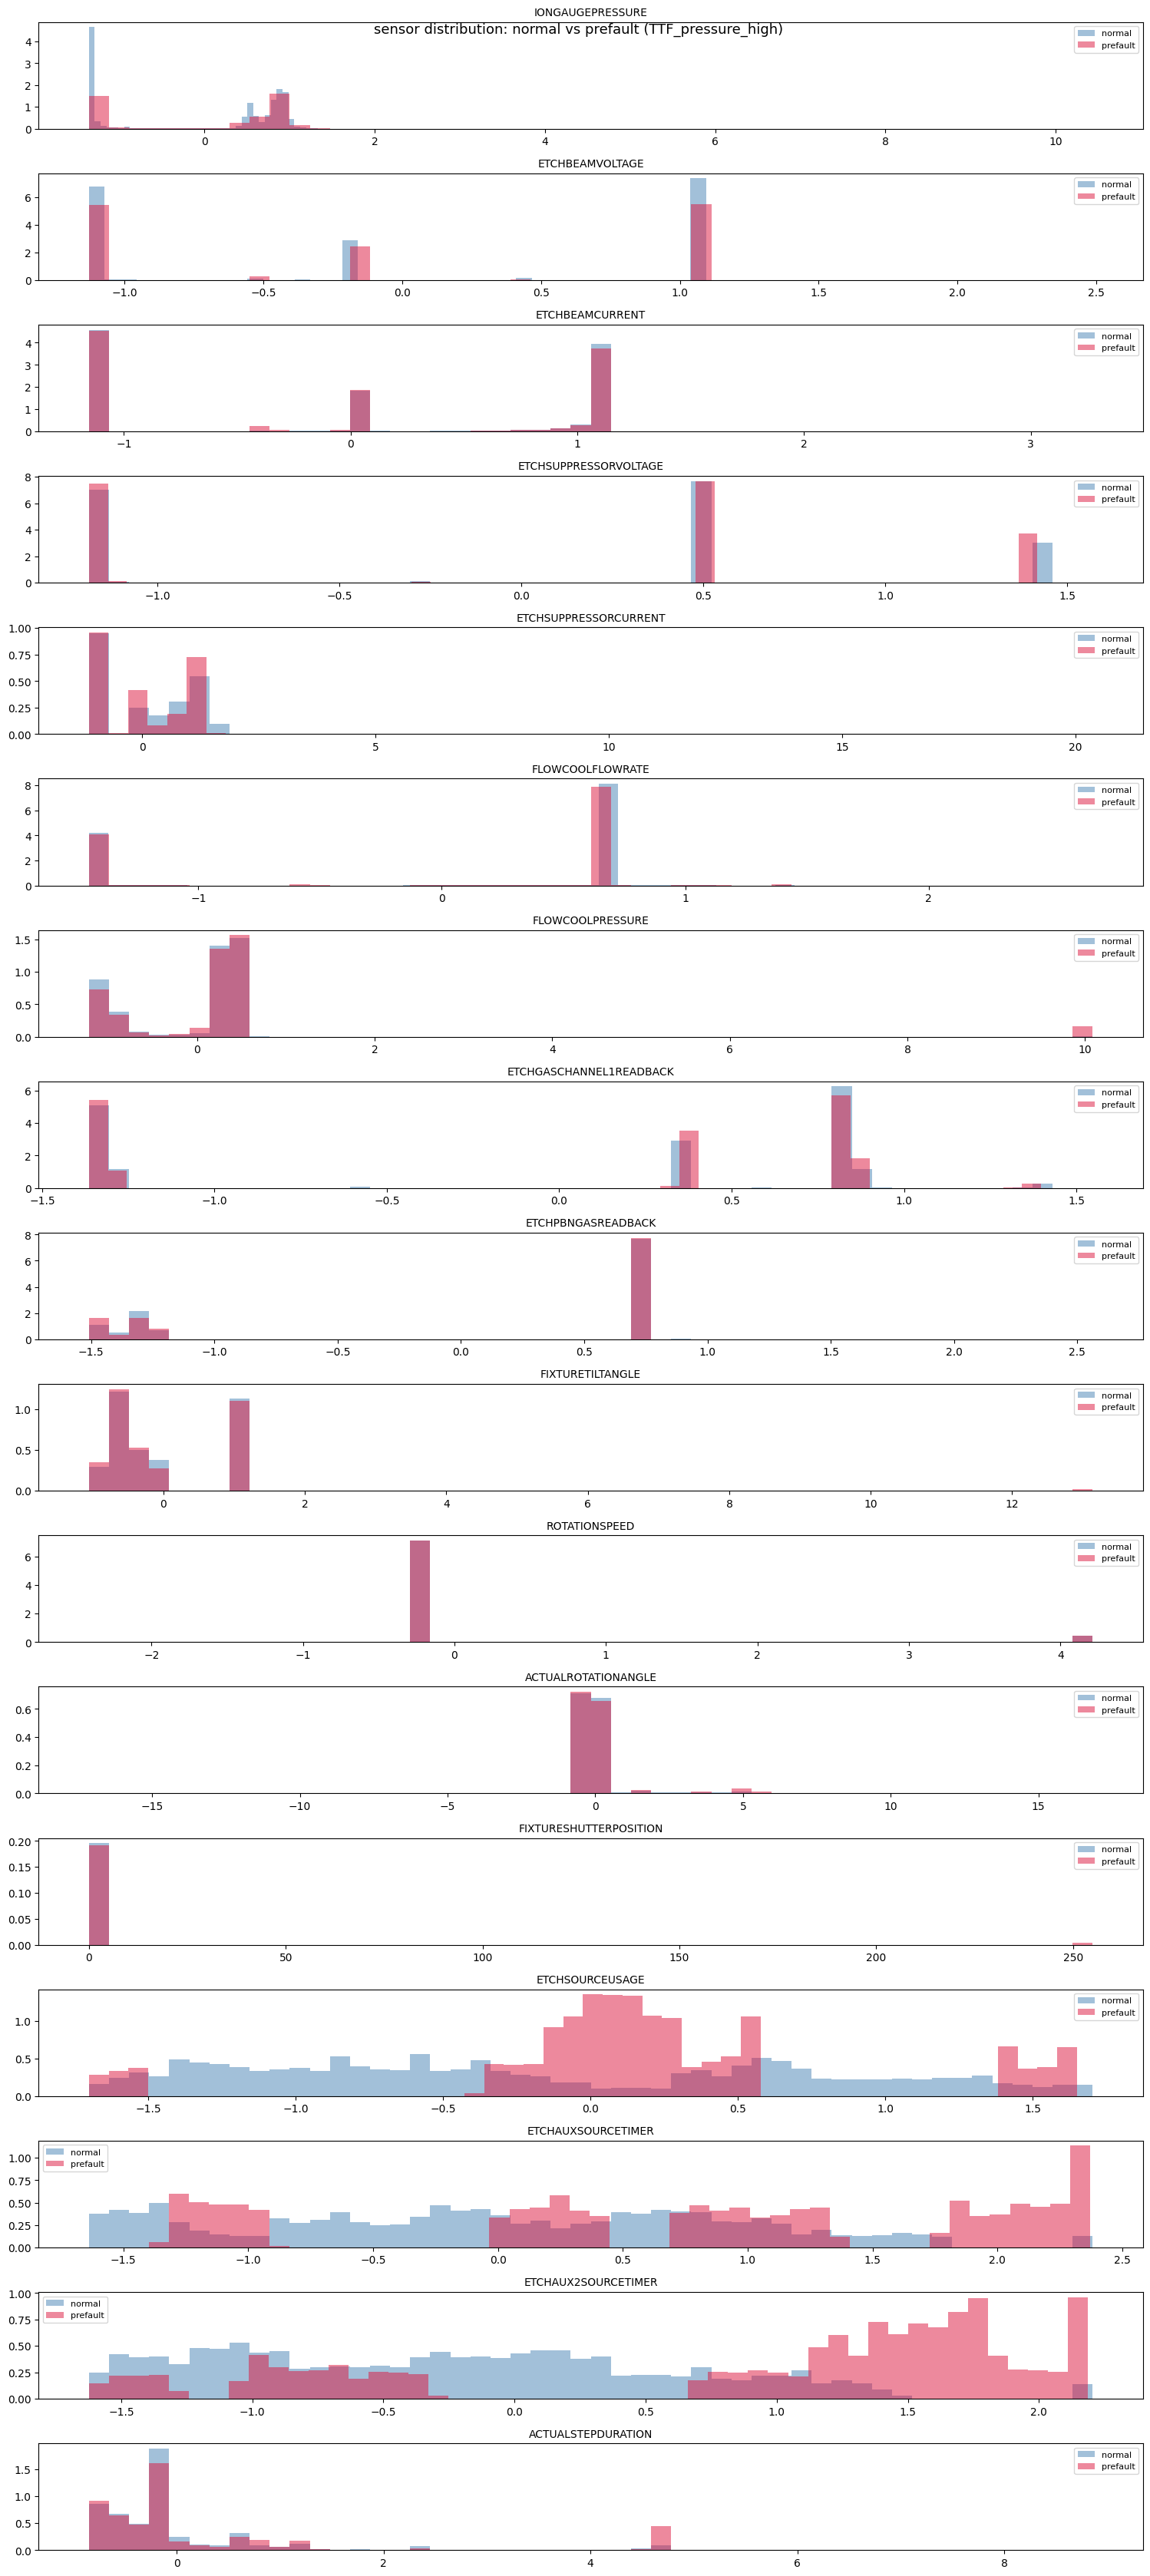

In [39]:
fig, axes = plt.subplots(len(train_cols), 1, figsize=(15, len(train_cols)*2))
axes = axes.flatten()

for i, col in enumerate(train_cols):
    axes[i].hist(df_normal[col].dropna(), bins=50, alpha=0.5,
                 color='steelblue', label='normal', density=True)
    axes[i].hist(df_prefault[col].dropna(), bins=50, alpha=0.5,
                 color='crimson', label='prefault', density=True)
    axes[i].set_title(col, fontsize=10)
    axes[i].legend(fontsize=8)

plt.suptitle("sensor distribution: normal vs prefault (TTF_pressure_high)", fontsize=13)
plt.tight_layout()
plt.show()

In [42]:
# 결측값 정당화
for col in ['ETCHSOURCEUSAGE', 'ETCHAUXSOURCETIMER', 'ETCHAUX2SOURCETIMER']:
  total = len(df_normal)
  missing = df_normal[col].isna().sum()
  print(f"{col}: 결측값 {missing:,}{missing/total*100: .2f}%")


ETCHSOURCEUSAGE: 결측값 0 0.00%
ETCHAUXSOURCETIMER: 결측값 0 0.00%
ETCHAUX2SOURCETIMER: 결측값 0 0.00%
